# Interpretabilidad — SHAP y LIME
**Proyecto:** Predicción de aceptación de depósito bancario (Bank Marketing)  
**Curso:** Aprendizaje de Máquina Aplicado — EAFIT 2026  

Este notebook es **completamente independiente** del resto del proyecto.  
Replica internamente el preprocesamiento y el pipeline del `eda_baseline.ipynb`  
y aplica SHAP y LIME sobre la Regresión Logística entrenada.

---
**Contenido:**
1. Instalación de dependencias
2. Configuración e imports
3. Carga de datos, preprocesamiento y entrenamiento
4. SHAP — Explicabilidad global y local
5. LIME — Explicaciones locales por instancia
6. Comparación SHAP vs LIME en la misma predicción

## 1. Instalación de dependencias
SHAP y LIME no están en `environment.yml` para no afectar el proyecto principal.

In [18]:
import subprocess, sys
for pkg in ['shap', 'lime']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('✔ shap y lime instalados.')

✔ shap y lime instalados.


## 2. Configuración e imports

In [19]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score

import shap
from lime import lime_tabular

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
PALETTE = ['#2C6EAB', '#E84855']

print('✔ Imports correctos.')

✔ Imports correctos.


## 3. Carga de datos, preprocesamiento y entrenamiento
Réplica exacta del pipeline del `eda_baseline.ipynb`.

In [20]:
df = pd.read_csv('../data/bank-full.csv', sep=';')
print(f'Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas')

TARGET       = 'y'
LEAKAGE_COLS = ['duration']

X = df.drop(columns=[TARGET] + LEAKAGE_COLS)
y = (df[TARGET] == 'yes').astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object', 'string']).columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
])

pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

pipeline_lr.fit(X_train, y_train)
y_proba = pipeline_lr.predict_proba(X_test)[:, 1]
y_pred  = pipeline_lr.predict(X_test)

print(f'Modelo entrenado.')
print(f'  ROC-AUC : {roc_auc_score(y_test, y_proba):.4f}')
print(f'  F1-score: {f1_score(y_test, y_pred):.4f}')

Dataset cargado: 45,211 filas x 17 columnas
Modelo entrenado.
  ROC-AUC : 0.7717
  F1-score: 0.2815


## 4. SHAP

SHAP responde: **¿cuánto contribuyó cada feature a desplazar la predicción desde el valor promedio?**

Usamos `shap.LinearExplainer` (optimizado para regresión logística) sobre los datos ya transformados.

In [21]:
prep = pipeline_lr.named_steps['preprocessor']
clf  = pipeline_lr.named_steps['classifier']

X_train_t = prep.transform(X_train)
X_test_t  = prep.transform(X_test)

ohe_names  = prep.named_transformers_['cat'].get_feature_names_out(cat_features).tolist()
feat_names = num_features + ohe_names

print(f'Total de features tras preprocesamiento: {len(feat_names)}')

Total de features tras preprocesamiento: 50


In [22]:
explainer   = shap.LinearExplainer(clf, X_train_t, feature_names=feat_names)
shap_values = explainer(X_test_t)

print(f'Valores SHAP calculados. Shape: {shap_values.values.shape}')

Valores SHAP calculados. Shape: (9043, 50)


### 4.1 Summary Plot — Importancia global de features

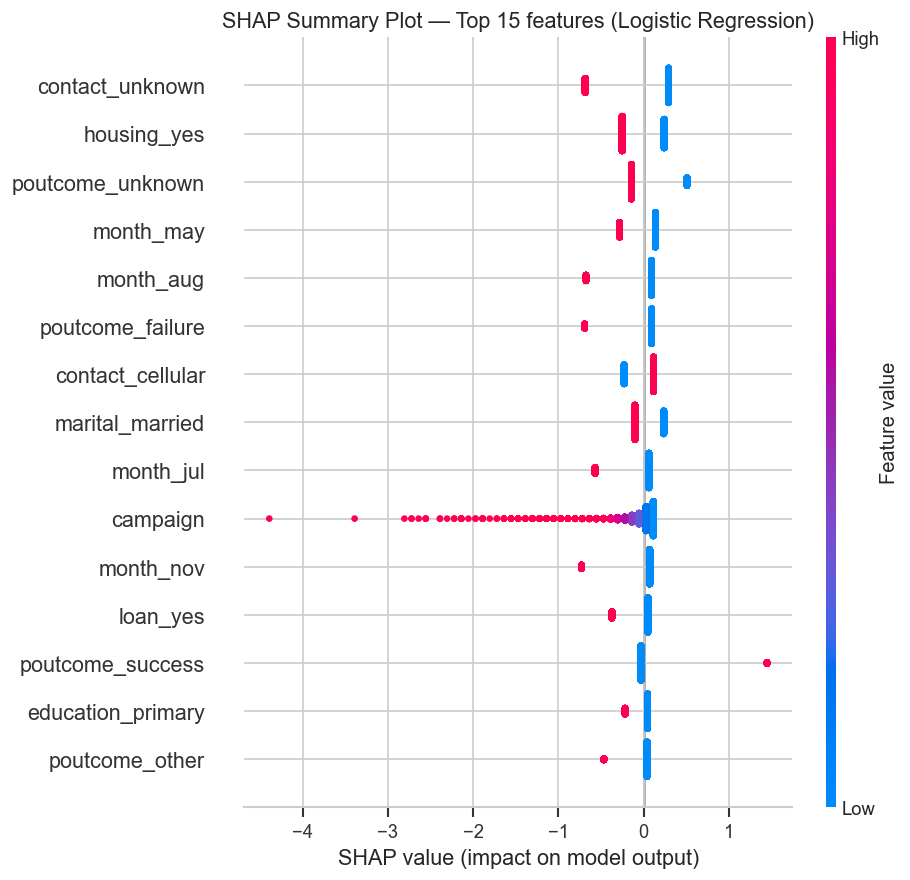

Cada punto = una instancia del test set.
Eje X: valor SHAP (positivo => empuja hacia yes, negativo => hacia no)
Color: valor real de la feature (rojo=alto, azul=bajo)


In [23]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values.values, X_test_t,
    feature_names=feat_names, max_display=15, show=False
)
plt.title('SHAP Summary Plot — Top 15 features (Logistic Regression)', fontsize=13)
plt.tight_layout()
plt.savefig('../figures/shap_summary_plot.png', bbox_inches='tight')
plt.show()

print('Cada punto = una instancia del test set.')
print('Eje X: valor SHAP (positivo => empuja hacia yes, negativo => hacia no)')
print('Color: valor real de la feature (rojo=alto, azul=bajo)')

### 4.2 Bar Plot — Top features por importancia media absoluta

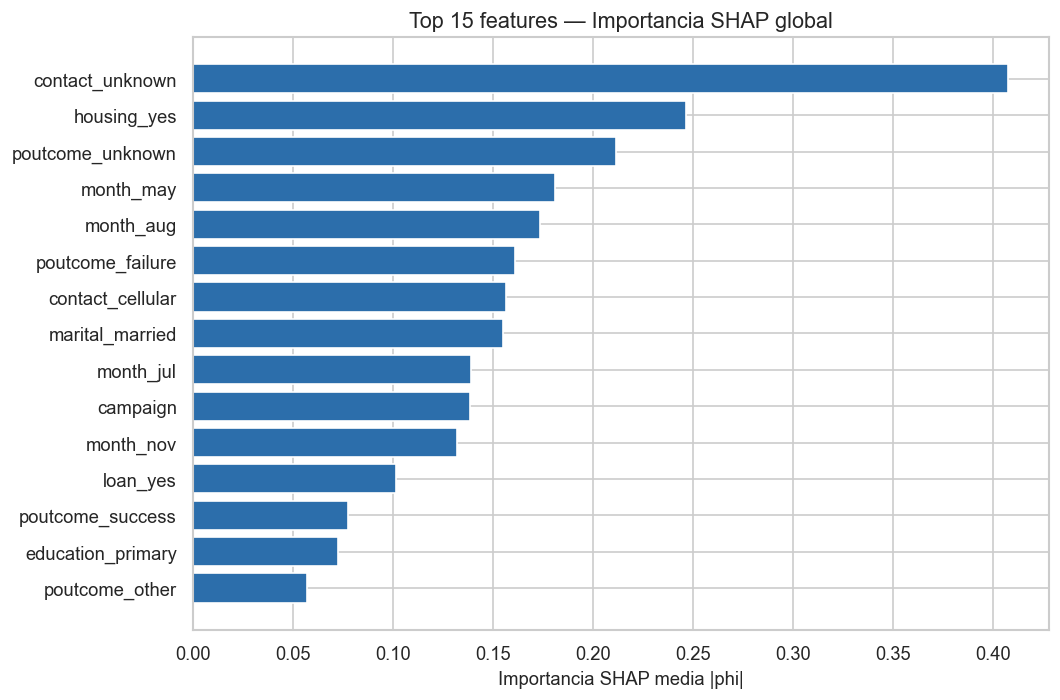

In [24]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
shap_df = (
    pd.DataFrame({'feature': feat_names, 'importance': mean_abs_shap})
    .sort_values('importance', ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(shap_df['feature'][::-1], shap_df['importance'][::-1],
        color='#2C6EAB', edgecolor='white')
ax.set_xlabel('Importancia SHAP media |phi|', fontsize=11)
ax.set_title('Top 15 features — Importancia SHAP global', fontsize=13)
plt.tight_layout()
plt.savefig('../figures/shap_bar_plot.png', bbox_inches='tight')
plt.show()

### 4.3 Waterfall Plot — Explicación de predicciones individuales

In [25]:
# Verdadero positivo (modelo predijo yes y acertó)
true_positives = np.where((y_pred == 1) & (y_test.values == 1))[0]
idx_tp = true_positives[0]
prob_tp = pipeline_lr.predict_proba(X_test.iloc[[idx_tp]])[0, 1]

print(f'Instancia TP (idx={idx_tp}): prob={prob_tp:.3f} | Real=YES')
print(X_test.iloc[idx_tp].to_string())

Instancia TP (idx=7): prob=0.840 | Real=YES
age                64
job           retired
marital      divorced
education     primary
default            no
balance           109
housing            no
loan               no
contact      cellular
day                23
month             jun
campaign            1
pdays             225
previous            2
poutcome      success


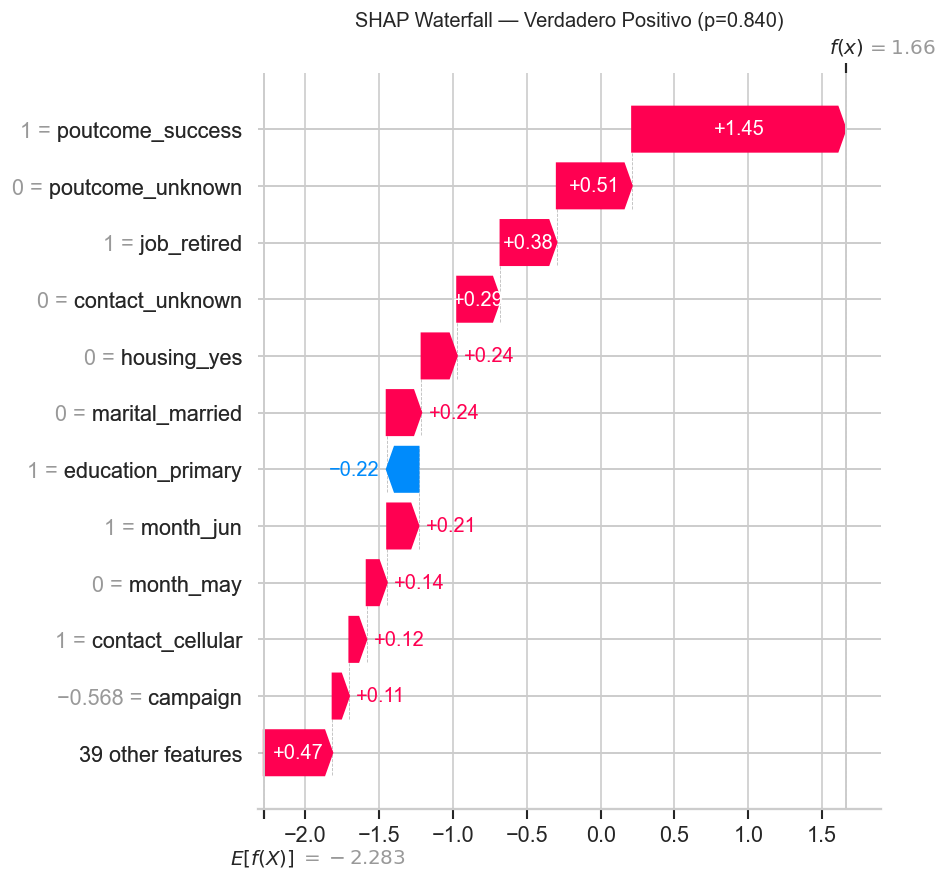

Barras rojas: empujan hacia yes | Barras azules: empujan hacia no
E[f(x)]: prediccion promedio del modelo.


In [26]:
plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_values[idx_tp], max_display=12, show=False)
plt.title(f'SHAP Waterfall — Verdadero Positivo (p={prob_tp:.3f})', fontsize=12)
plt.tight_layout()
plt.savefig('../figures/shap_waterfall_tp.png', bbox_inches='tight')
plt.show()

print('Barras rojas: empujan hacia yes | Barras azules: empujan hacia no')
print('E[f(x)]: prediccion promedio del modelo.')

Instancia FN (idx=18): prob=0.470 | Real=YES <- falso negativo


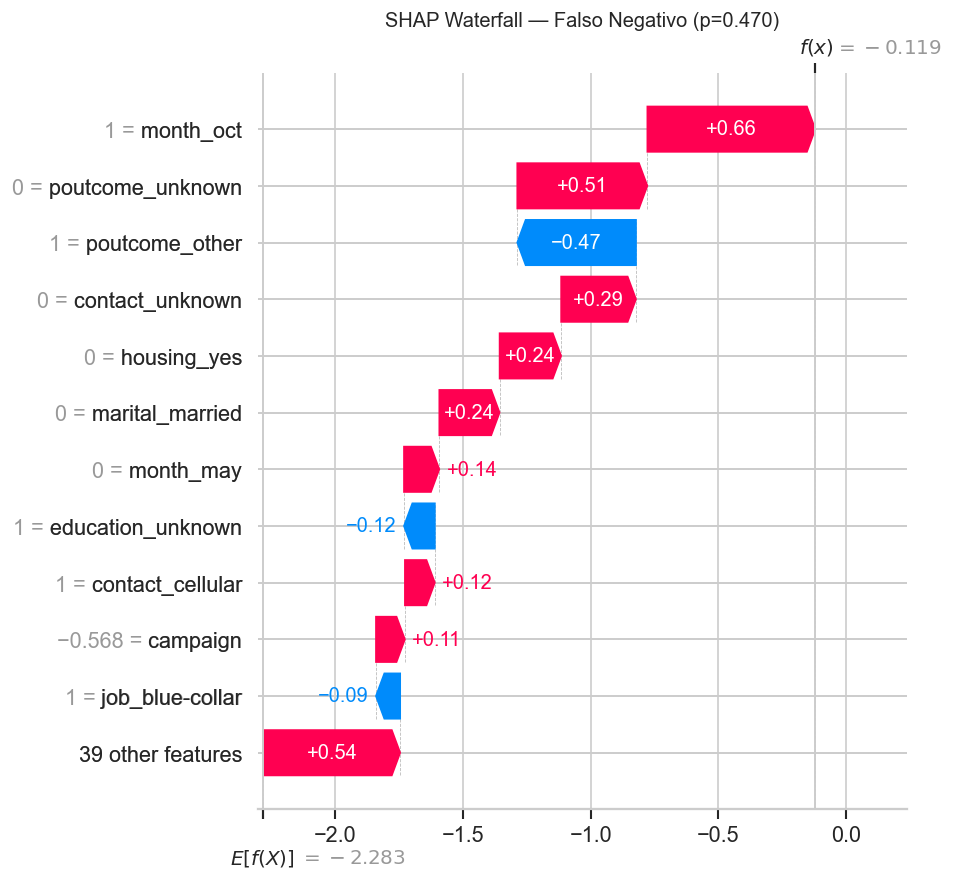

Aqui se puede ver que features confundieron al modelo.


In [27]:
# Falso negativo (el modelo no detectó un yes real)
false_negatives = np.where((y_pred == 0) & (y_test.values == 1))[0]
idx_fn = false_negatives[0]
prob_fn = pipeline_lr.predict_proba(X_test.iloc[[idx_fn]])[0, 1]

print(f'Instancia FN (idx={idx_fn}): prob={prob_fn:.3f} | Real=YES <- falso negativo')

plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_values[idx_fn], max_display=12, show=False)
plt.title(f'SHAP Waterfall — Falso Negativo (p={prob_fn:.3f})', fontsize=12)
plt.tight_layout()
plt.savefig('../figures/shap_waterfall_fn.png', bbox_inches='tight')
plt.show()

print('Aqui se puede ver que features confundieron al modelo.')

### 4.4 Dependence Plot

Feature mas importante segun SHAP: "contact_unknown"


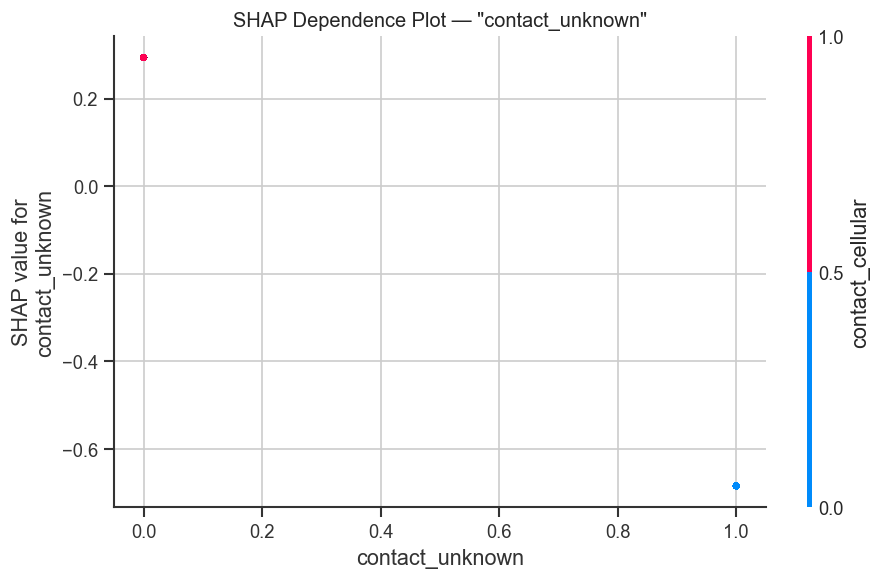

In [28]:
top_feature_name = shap_df.iloc[0]['feature']
top_feature_idx  = feat_names.index(top_feature_name)
print(f'Feature mas importante segun SHAP: "{top_feature_name}"')

fig, ax = plt.subplots(figsize=(8, 5))
shap.dependence_plot(
    top_feature_idx, shap_values.values, X_test_t,
    feature_names=feat_names, ax=ax, show=False
)
ax.set_title(f'SHAP Dependence Plot — "{top_feature_name}"', fontsize=12)
plt.tight_layout()
plt.savefig('../figures/shap_dependence_plot.png', bbox_inches='tight')
plt.show()

## 5. LIME

LIME responde: **¿qué modelo lineal simple aproxima el modelo complejo alrededor de esta predicción concreta?**

**Nota técnica:** LIME requiere un array 100% numérico. Las variables categóricas se codifican
como índices enteros con `OrdinalEncoder`. El `predict_fn` los decodifica de vuelta a strings
antes de pasárselos al pipeline original.

In [29]:
# Codificador ordinal para categóricas (solo para LIME, no toca el pipeline principal)
ord_enc = OrdinalEncoder(
    handle_unknown='use_encoded_value', unknown_value=-1, dtype=np.float64
)
ord_enc.fit(X_train[cat_features])

col_list = X_train.columns.tolist()
cat_idxs = [col_list.index(c) for c in cat_features]
cat_names = {
    col_list.index(c): list(cats)
    for c, cats in zip(cat_features, ord_enc.categories_)
}

def encode_for_lime(X_df):
    """DataFrame con strings -> array float para LIME."""
    X_enc = X_df.copy()
    X_enc[cat_features] = ord_enc.transform(X_df[cat_features])
    return X_enc.astype(np.float64).values

X_train_lime = encode_for_lime(X_train)

lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data        = X_train_lime,
    feature_names        = col_list,
    class_names          = ['no (0)', 'yes (1)'],
    categorical_features = cat_idxs,
    categorical_names    = cat_names,
    mode                 = 'classification',
    random_state         = RANDOM_STATE
)

print('LIME explainer configurado.')
print(f'  {X_train.shape[1]} features originales | categoricas codificadas como indices')

LIME explainer configurado.
  15 features originales | categoricas codificadas como indices


In [30]:
# predict_fn: LIME pasa arrays float -> decodificamos strings -> llamamos al pipeline
def predict_fn(X_array):
    X_df = pd.DataFrame(X_array, columns=col_list)
    for i, col in enumerate(cat_features):
        cats = ord_enc.categories_[i]
        idxs = X_df[col].round().astype(int).clip(0, len(cats) - 1)
        X_df[col] = cats[idxs]
    for col in num_features:
        X_df[col] = pd.to_numeric(X_df[col])
    return pipeline_lr.predict_proba(X_df)

### 5.1 Explicación LIME — Verdadero Positivo

Instancia: idx=7 | Prob modelo: 0.840 | Real: YES
Prob estimada por LIME: 0.660


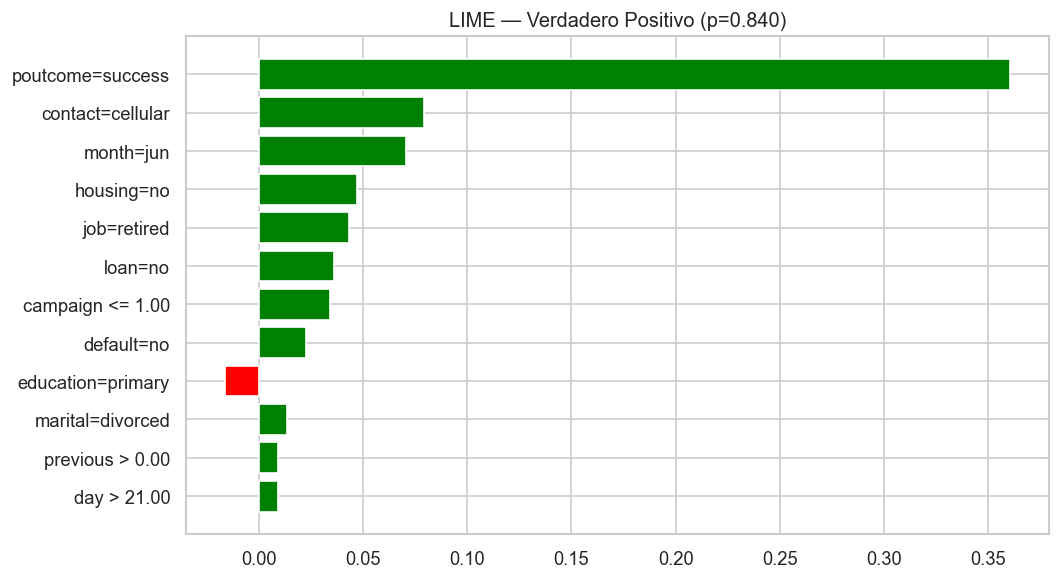

Verde: features que empujan hacia yes | Rojo: features que empujan hacia no


In [31]:
exp_tp = lime_explainer.explain_instance(
    data_row   = encode_for_lime(X_test.iloc[[idx_tp]])[0],
    predict_fn = predict_fn,
    num_features = 12,
    num_samples  = 3000,
    labels       = (1,)
)

print(f'Instancia: idx={idx_tp} | Prob modelo: {prob_tp:.3f} | Real: YES')
print(f'Prob estimada por LIME: {exp_tp.local_pred[0]:.3f}')

fig = exp_tp.as_pyplot_figure(label=1)
fig.set_size_inches(9, 5)
plt.title(f'LIME — Verdadero Positivo (p={prob_tp:.3f})', fontsize=12)
plt.tight_layout()
plt.savefig('../figures/lime_tp.png', bbox_inches='tight')
plt.show()

print('Verde: features que empujan hacia yes | Rojo: features que empujan hacia no')

### 5.2 Explicación LIME — Falso Negativo

Instancia: idx=18 | Prob modelo: 0.470 | Real: YES (falso negativo)
Prob estimada por LIME: 0.397


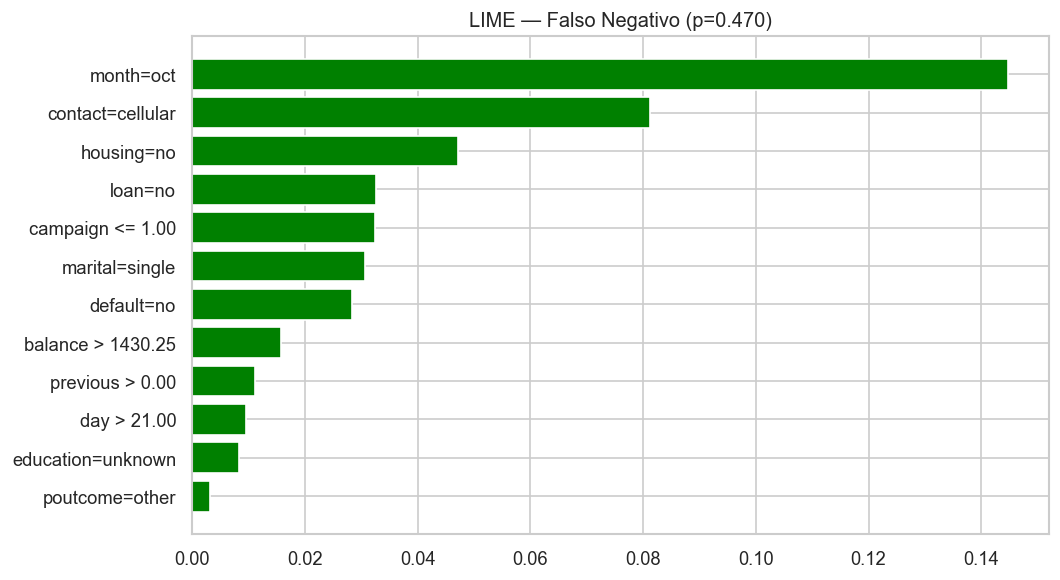

In [32]:
exp_fn = lime_explainer.explain_instance(
    data_row   = encode_for_lime(X_test.iloc[[idx_fn]])[0],
    predict_fn = predict_fn,
    num_features = 12,
    num_samples  = 3000,
    labels       = (1,)
)

print(f'Instancia: idx={idx_fn} | Prob modelo: {prob_fn:.3f} | Real: YES (falso negativo)')
print(f'Prob estimada por LIME: {exp_fn.local_pred[0]:.3f}')

fig = exp_fn.as_pyplot_figure(label=1)
fig.set_size_inches(9, 5)
plt.title(f'LIME — Falso Negativo (p={prob_fn:.3f})', fontsize=12)
plt.tight_layout()
plt.savefig('../figures/lime_fn.png', bbox_inches='tight')
plt.show()

## 6. Comparación SHAP vs LIME en la misma instancia

Comparación de lo que atribuye cada método a las mismas features para la **misma predicción**.

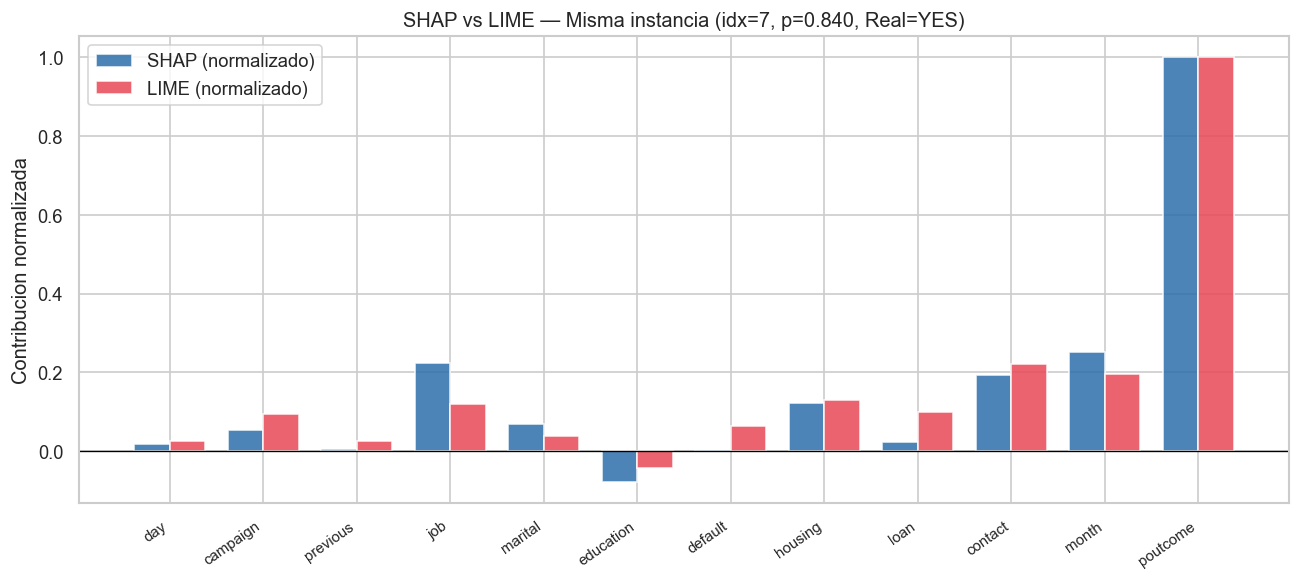

Donde coinciden: efecto robusto de la feature.
Donde difieren: LIME es aproximacion local; SHAP tiene garantias teoricas.


In [33]:
# SHAP: agrupar contribuciones OHE de vuelta a features originales
shap_vals_tp = shap_values[idx_tp].values

shap_orig = {}
for i, col in enumerate(num_features):
    shap_orig[col] = shap_vals_tp[i]

ohe = prep.named_transformers_['cat']
offset = len(num_features)
for j, col in enumerate(cat_features):
    n_cats = len(ohe.categories_[j])
    shap_orig[col] = shap_vals_tp[offset: offset + n_cats].sum()
    offset += n_cats

# LIME: mapear condiciones a nombres de features originales
lime_weights = dict(exp_tp.as_list(label=1))
lime_orig = {}
for feature_name in col_list:
    for cond, weight in lime_weights.items():
        if feature_name in cond:
            lime_orig[feature_name] = weight
            break

# Features presentes en ambos
common = [f for f in shap_orig if f in lime_orig]

def normalize(v):
    mx = np.abs(v).max()
    return v / mx if mx > 0 else v

shap_norm = normalize(np.array([shap_orig[f] for f in common]))
lime_norm = normalize(np.array([lime_orig[f] for f in common]))

x = np.arange(len(common))
width = 0.38

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width/2, shap_norm, width, label='SHAP (normalizado)', color='#2C6EAB', alpha=0.85)
ax.bar(x + width/2, lime_norm, width, label='LIME (normalizado)', color='#E84855', alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(common, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Contribucion normalizada')
ax.set_title(f'SHAP vs LIME — Misma instancia (idx={idx_tp}, p={prob_tp:.3f}, Real=YES)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('../figures/shap_vs_lime_comparison.png', bbox_inches='tight')
plt.show()

print('Donde coinciden: efecto robusto de la feature.')
print('Donde difieren: LIME es aproximacion local; SHAP tiene garantias teoricas.')

## 7. Resumen de hallazgos

| Aspecto | SHAP | LIME |
|---|---|---|
| Ambito | Local y global | Solo local |
| Base teorica | Valores de Shapley (teoria de juegos) | Modelo lineal de aproximacion local |
| Estabilidad | Alta — determinista dado el modelo | Media — depende del muestreo aleatorio |
| Costo computacional | Bajo con LinearExplainer | Medio (3000 muestras por instancia) |

**Conclusion:**  
Para este proyecto (Logistic Regression, datos tabulares), SHAP es la herramienta mas adecuada
porque tiene garantias teoricas y permite comparacion global. LIME es util para validar
explicaciones individuales y como contraste pedagogico.